In [52]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rk4(params, f, yo, t0, tf, h, N):
    C2 = params["C2"]
    C3 = params["C3"]
    C4 = params["C4"]
    
    A21 = params["A21"]
    A31 = params["A31"] 
    A32 = params["A32"]
    A41 = params["A41"]
    A42 = params["A42"]
    A43 = params["A43"]
    
    B1 = params["B1"]
    B2 = params["B2"]
    B3 = params["B3"]
    B4 = params["B4"]
    
    Y = [yo]
    T = [t0]
    
    for i in range(N):
        t_n = T[-1]
        y_n = Y[-1]
        
        k1 = f(t_n, y_n)
        k2 = f(t_n + h*C2, y_n + h*A21*k1)
        k3 = f(t_n + h*C3, y_n + h*(A31*k1 + A32*k2))
        k4 = f(t_n + h*C4, y_n + h*(A41*k1 + A42*k2 + A43*k3))
        
        y_next = y_n + h*(B1*k1 + B2*k2 + B3*k3 + B4*k4)
        t_next = t_n + h
        
        Y.append(y_next)
        T.append(t_next)
    
    return np.array(T), np.array(Y)

def xdot(t, x, y, z):
    return - y - z

def ydot(t, x, y, z, a):    
    return x + a * y

def zdot(t, x, y, z, b, c):
    return b + z * (x - c)

def sistema(t, Y, a, b, c):
    x, y, z = Y
    return np.array([xdot(t, x, y, z),
        ydot(t, x, y, z, a),
        zdot(t, x, y, z, b, c)])

def multipaso(f, y0, t0, h, params_, a, b, c, N):
    
    def f_(t, Y):
        return sistema(t, Y, a, b, c)
    
    T_rk, Y_rk = rk4(params_, f_, y0, t0, t0 + 3*h, h, N)
    tiempos = list(T_rk)
    valores = list(Y_rk)

    for i in range(3, N):
        t_n = tiempos[i]
        y_n = valores[i]
        t_n1 = tiempos[i-1]
        y_n1 = valores[i-1]
        t_n2 = tiempos[i-2]
        y_n2 = valores[i-2]
        t_n3 = tiempos[i-3]
        y_n3 = valores[i-3]
        
        f_n = sistema(t_n, y_n, a, b, c)
        f_n1 = sistema(t_n1, y_n1, a, b, c)
        f_n2 = sistema(t_n2, y_n2, a, b, c)
        f_n3 = sistema(t_n3, y_n3, a, b, c)
        
        y_pred = y_n + (h/24)*(55*f_n - 59*f_n1 + 37*f_n2 - 9*f_n3)
        t_sig = t_n + h
        f_pred = sistema(t_sig, y_pred, a, b, c)
        y_sig = y_n + (h/24)*(9*f_pred + 19*f_n - 5*f_n1 + f_n2)
        
        tiempos.append(t_sig)
        valores.append(y_sig)
    
    return np.array(tiempos), np.array(valores)

params_ = {"C2": 0.5, "C3": 0.5, "C4": 1.0, "A21": 0.5, "A31": 0, "A32": 0.5, "A41": 0, "A42": 0, "A43": 1.0, "B1": 1/6, "B2": 1/3, "B3": 1/3, "B4": 1/6}

yo = np.array([0.1, 0.0, 0.0])
N = 6000
h = 0.05
a = 0.1
b = 0.1
c = 19

T, Y = multipaso(sistema, yo, 0, h, params_, a, b, c, N)
x = Y[:, 0]
y = Y[:, 1]
z = Y[:, 2]

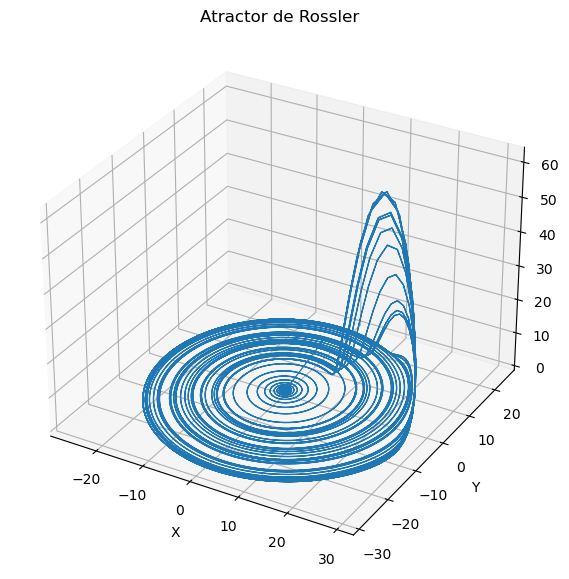

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, lw=0.9)

ax.set_title("Atractor de Rossler")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()